In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

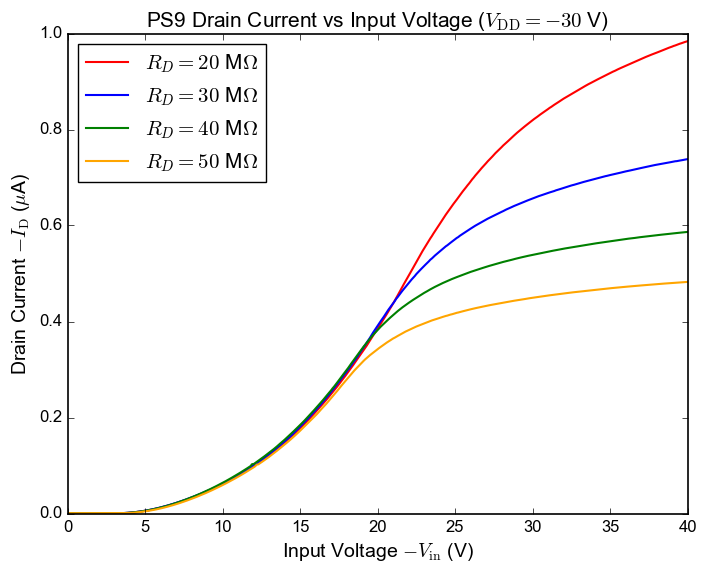

In [26]:
data1 = np.loadtxt("./Data-20260705/20260705001.dat")
data2 = np.loadtxt("./Data-20260705/20260705002.dat")
data3 = np.loadtxt("./Data-20260705/20260705003.dat")
data4 = np.loadtxt("./Data-20260705/20260705006.dat")

datasets = [
    (r'$R_D = 20 ~$M$\Omega$', 20e6, data2, 'red'),
    (r'$R_D = 30 ~$M$\Omega$', 30e6, data1, 'blue'),
    (r'$R_D = 40 ~$M$\Omega$', 40e6, data3, 'green'),
    (r'$R_D = 50 ~$M$\Omega$', 50e6, data4, 'orange'),
]
for label, R_D, data, color in datasets:
    V_GS = data[:, 0]
    I_D = data[:, 1]
    V_DS = data[:, 2]
    V_out = V_DS - I_D * R_D
    V_in = V_GS
    plt.plot(-V_in, -I_D*1e6, lw=1.5, linestyle='-', color=color, label=label)

plt.xlabel(r'Input Voltage $-V_\text{in}$ (V)', fontsize=14)
plt.ylabel(r'Drain Current $-I_\text{D}$ ($\mu$A)', fontsize=14)
plt.xlim(0, 40)
plt.title(r'PS9 Drain Current vs Input Voltage ($V_\text{DD} = -30$ V)', fontsize=15)
plt.legend(frameon=True, loc='upper left', fontsize=15, numpoints=1)
plt.show()



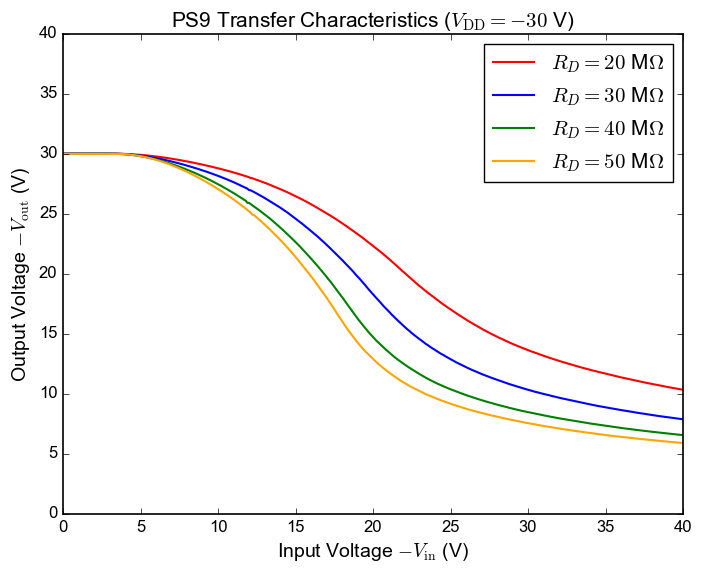

In [ ]:
for label, R_D, data, color in datasets:
    V_GS = data[:, 0]
    I_D = data[:, 1]
    V_DS = data[:, 2]
    V_out = V_DS - I_D * R_D
    V_in = V_GS
    plt.plot(-V_in, -V_out, lw=1.5, linestyle='-', color=color, label=label)
plt.xlabel(r'Input Voltage $-V_\text{in}$ (V)', fontsize=14)
plt.ylabel(r'Output Voltage $-V_\text{out}$ (V)', fontsize=14)
plt.xlim(0, 40)
plt.ylim(0, 40)
plt.title(r'PS9 Transfer Characteristics ($V_\text{DD} = -30$ V)', fontsize=15)
plt.legend(frameon=True, loc='upper right', fontsize=15, numpoints=1)
# plt.savefig("amplifier-PS9-transfer.eps", format='eps', bbox_inches='tight')
plt.show()


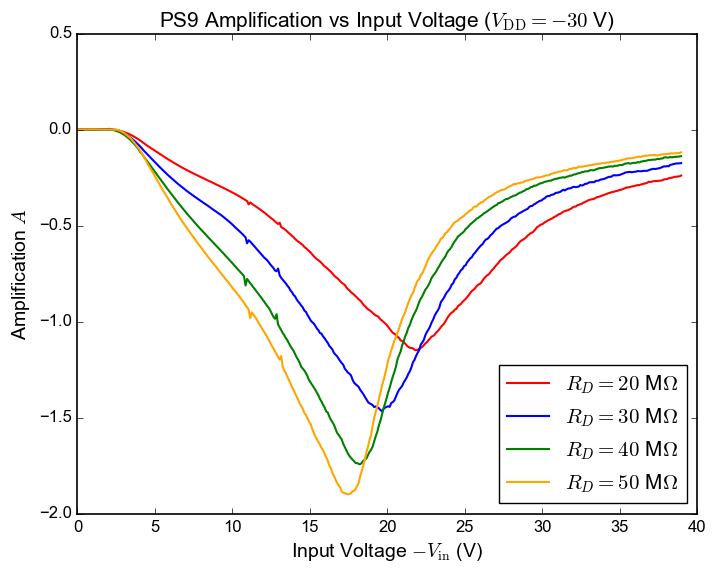

In [ ]:
for label, R_D, data, color in datasets:
    V_GS = data[:, 0]
    I_D = data[:, 1]
    V_DS = data[:, 2]
    V_out = V_DS - I_D * R_D
    V_in = V_GS
    A = np.diff(V_out) / np.diff(V_in)

    window_size = 20
    window = np.ones(window_size) / window_size

    V_in_smooth = np.convolve(V_in, window, mode='same')
    A_smooth = np.convolve(A, window, mode='same')
    plt.plot(-V_in_smooth[15:-10], A_smooth[15:-9], lw=1.5, linestyle='-', color=color, label=label)
plt.xlabel(r'Input Voltage $-V_\text{in}$ (V)', fontsize=14)
plt.ylabel(r'Amplification $A$', fontsize=14)
plt.xlim(0, 40)
plt.title(r'PS9 Amplification vs Input Voltage ($V_\text{DD} = -30$ V)', fontsize=15)
plt.legend(frameon=True, loc='lower right', fontsize=15, numpoints=1)
# plt.savefig("amplifier-PS9-amp.eps", format='eps', bbox_inches='tight')
plt.show()